Load necessary packages

In [16]:
# only sources used were the provided course materials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Load dataset

In [ ]:
churn_data = pd.read_csv('churn_clean.csv')

Extract the variables of interest

In [3]:
kmeans_data = churn_data[[
    "Outage_sec_perweek",
    "Income",
    "Tenure",
    "MonthlyCharge",
    "Bandwidth_GB_Year"
]].copy()

Preprocess Data

In [4]:
# check for duplicates
print(kmeans_data.duplicated().sum())

# no duplicates found, so no need to drop any rows

0


In [5]:
# check data types
print(kmeans_data.dtypes)

#all data type are correct, so no need to change any data types

Outage_sec_perweek    float64
Income                float64
Tenure                float64
MonthlyCharge         float64
Bandwidth_GB_Year     float64
dtype: object


In [6]:
# check for missing values
print(kmeans_data.isna().sum())

# there are no missing values, so no changes are needed

Outage_sec_perweek    0
Income                0
Tenure                0
MonthlyCharge         0
Bandwidth_GB_Year     0
dtype: int64


In [7]:
# check for outliers
for col in kmeans_data.columns:
    Q1 = kmeans_data[col].quantile(0.25)
    Q3 = kmeans_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((kmeans_data[col] < lower) |
                  (kmeans_data[col] > upper)).sum()

    print(f"{col}: {n_outliers} outliers")

Outage_sec_perweek: 76 outliers
Income: 336 outliers
Tenure: 0 outliers
MonthlyCharge: 0 outliers
Bandwidth_GB_Year: 0 outliers


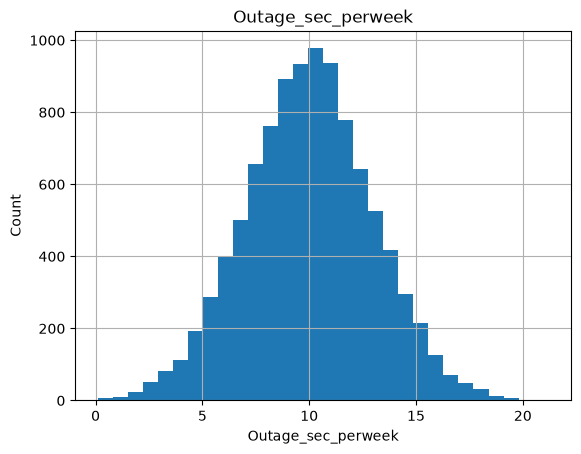

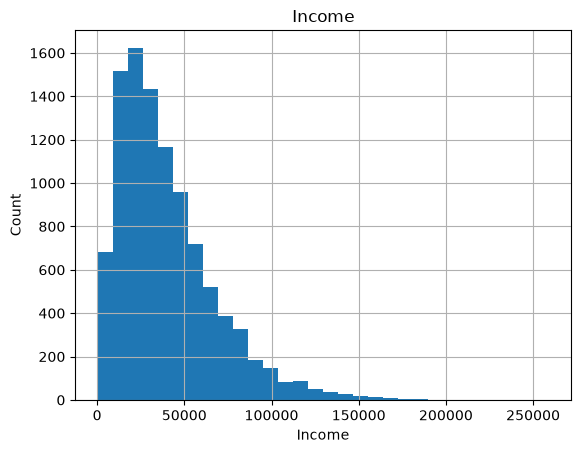

Top 20 values for Income:
4249    258900.70
9180    256998.40
6649    231252.00
5599    220383.00
5801    212255.30
6594    196746.00
6837    194550.70
3985    189938.40
8830    186156.60
972     186035.04
2762    175137.30
9249    173978.00
656     172884.11
3782    172372.20
685     169580.73
688     168097.10
6130    167846.00
3132    167566.60
3953    166553.10
1725    165151.02
Name: Income, dtype: float64
Top 20 values for Outage_sec_perweek:
4190    21.207230
5392    20.625040
2927    20.304620
5363    19.717560
8539    19.657110
2250    19.500580
1022    19.267782
4562    19.261110
8968    19.209690
7953    19.107810
868     19.081685
527     19.071806
5680    19.019620
8643    19.016290
1306    18.942892
3957    18.851730
3219    18.787050
2571    18.779150
8237    18.450230
2488    18.440590
Name: Outage_sec_perweek, dtype: float64
Bottom 20 values for Outage_sec_perweek:
8194    0.099747
1334    0.120058
3629    0.232279
4427    0.355048
6463    0.391866
1997    0.507375
190

In [8]:
# investigate outliers in outage_sec_perweek and income

# plot histograms for the two variables with outliers to visualize the distribution of the data
variables = ["Outage_sec_perweek", "Income"]

for var in variables:
    kmeans_data[var].hist(bins=30)
    plt.title(var)
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.show()

# print the 20 highest values in income, and 20 highest and lowest values in outage_sec_perweek to investigate the outliers
print(f"Top 20 values for Income:\n{kmeans_data['Income'].nlargest(20)}")
print(f"Top 20 values for Outage_sec_perweek:\n{kmeans_data['Outage_sec_perweek'].nlargest(20)}")
print(f"Bottom 20 values for Outage_sec_perweek:\n{kmeans_data['Outage_sec_perweek'].nsmallest(20)}")

# after further investigation, the outliers appear to be valid data points so no changes will be made


In [9]:
# standardize the data
scaler = StandardScaler()
kmeans_data_scaled = pd.DataFrame(scaler.fit_transform(kmeans_data), columns=kmeans_data.columns)

print(kmeans_data_scaled.head())

   Outage_sec_perweek    Income    Tenure  MonthlyCharge  Bandwidth_GB_Year
0           -0.679978 -0.398778 -1.048746      -0.003943          -1.138487
1            0.570331 -0.641954 -1.262001       1.630326          -1.185876
2            0.252347 -1.070885 -0.709940      -0.295225          -0.612138
3            1.650506 -0.740525 -0.659524      -1.226521          -0.561857
4           -0.623156  0.009478 -1.242551      -0.528086          -1.428184


In [10]:
# output the cleaned data to a new CSV file
kmeans_data_scaled.to_csv('/Users/stevenphillips/Documents/WGU/D603/d603-machine-learning/kmeans_data_scaled.csv', index=False)

Perform K-means clustering

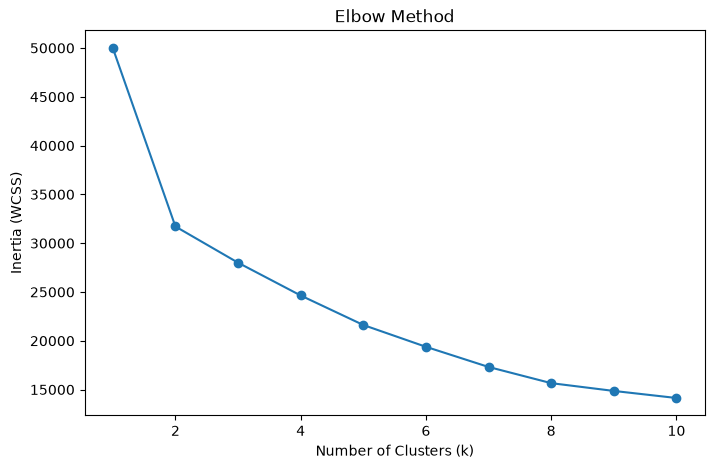

In [11]:
# plot the inertia to find the optimal number of clusters
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(kmeans_data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()

In [12]:
# fit the KMeans model with the optimal number of clusters (k=2)
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(kmeans_data_scaled)

In [13]:
# add the cluster labels to the original data
kmeans_data_clustered = kmeans_data.copy()
kmeans_data_clustered["Cluster"] = cluster_labels

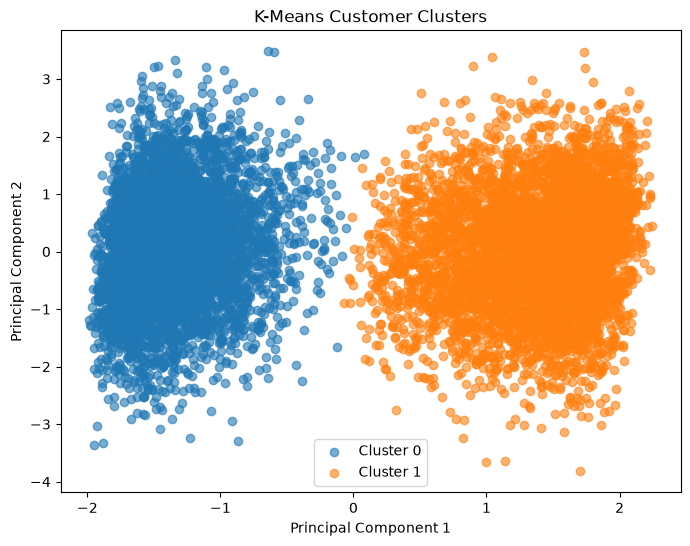

In [14]:
# reduce the standardized variables to two principal components to match the number of clusters
pca = PCA(n_components=2)
pca_data = pca.fit_transform(kmeans_data_scaled)

# Create a DataFrame for plotting
cluster_plot = pd.DataFrame(
    pca_data,
    columns=["Principal Component 1", "Principal Component 2"]
)

cluster_plot["Cluster"] = cluster_labels

# Plot the clusters
plt.figure(figsize=(8, 6))

for cluster in sorted(cluster_plot["Cluster"].unique()):
    cluster_points = cluster_plot[cluster_plot["Cluster"] == cluster]

    plt.scatter(
        cluster_points["Principal Component 1"],
        cluster_points["Principal Component 2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Customer Clusters")
plt.legend()
plt.show()

In [15]:
# create a summary of the clusters
cluster_summary = (
    kmeans_data
    .assign(Cluster=cluster_labels)
    .groupby("Cluster")
    .mean()
    .round(2)
)

print(cluster_summary)

         Outage_sec_perweek    Income  Tenure  MonthlyCharge  \
Cluster                                                        
0                      9.99  39748.26    9.13         172.73   
1                     10.01  39865.61   59.93         172.52   

         Bandwidth_GB_Year  
Cluster                     
0                  1312.29  
1                  5473.23  


In [17]:
# analyze cluster quality using silhouette score
silhouette_avg = silhouette_score(kmeans_data_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.3576
